# FER2013 — Architecture 4: Compact ResNet

## 1. Setup

In [40]:
!pip install wandb onnx -q

import os, random, time
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import wandb

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

NUM_WORKERS = 2
print("DataLoader workers:", NUM_WORKERS)

DATA_DIR = "data"
EMOTIONS = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
NUM_CLASSES = len(EMOTIONS)

Using device: cuda
DataLoader workers: 2


In [16]:
if not os.path.exists("data/icml_face_data.csv"):
    from google.colab import drive
    drive.mount('/content/drive')
    !mkdir -p data && cp "/content/drive/MyDrive/icml_face_data.csv" data/
else:
    print("data/icml_face_data.csv already present - skipping Drive copy.")

data/icml_face_data.csv already present - skipping Drive copy.


## 2. Data loading & splits

In [17]:
df = pd.read_csv(f"{DATA_DIR}/icml_face_data.csv")
df.columns = [c.strip() for c in df.columns]

def pixels_to_array(frame):
    X = np.stack([np.asarray(p.split(), dtype=np.uint8) for p in frame["pixels"]])
    return X.reshape(-1, 48, 48)

train_df = df[df["Usage"] == "Training"].reset_index(drop=True)
val_df   = df[df["Usage"] == "PublicTest"].reset_index(drop=True)
test_df  = df[df["Usage"] == "PrivateTest"].reset_index(drop=True)

X_train = pixels_to_array(train_df); y_train = train_df["emotion"].to_numpy()
X_val   = pixels_to_array(val_df);   y_val   = val_df["emotion"].to_numpy()
X_test  = pixels_to_array(test_df);  y_test  = test_df["emotion"].to_numpy()

MEAN = float(X_train.mean() / 255.0)
STD  = float(X_train.std()  / 255.0)
print(f"train {X_train.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"normalized mean/std (train): {MEAN:.4f} / {STD:.4f}")

counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = counts.sum() / (NUM_CLASSES * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
for i, e in enumerate(EMOTIONS):
    print(f"{e:9s} n={counts[i]:5d}  weight={class_weights[i]:.2f}")

train (28709, 48, 48)  val (3589, 48, 48)  test (3589, 48, 48)
normalized mean/std (train): 0.5077 / 0.2550
Angry     n= 3995  weight=1.03
Disgust   n=  436  weight=9.41
Fear      n= 4097  weight=1.00
Happy     n= 7215  weight=0.57
Sad       n= 4830  weight=0.85
Surprise  n= 3171  weight=1.29
Neutral   n= 4965  weight=0.83


## 3. Dataset & transforms

In [41]:
class FER2013Dataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.aug = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.RandomResizedCrop(48, scale=(0.85, 1.0), antialias=True),
        ])
        self.normalize = transforms.Normalize(mean=[MEAN], std=[STD])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx]).float().div(255.0).unsqueeze(0)
        if self.augment:
            img = self.aug(img)
        return self.normalize(img), self.y[idx]


def make_loaders(batch_size=64, augment=True, num_workers=0,
                 pin_memory=None, persistent_workers=None):
    tr = FER2013Dataset(X_train, y_train, augment=augment)
    va = FER2013Dataset(X_val,   y_val,   augment=False)
    te = FER2013Dataset(X_test,  y_test,  augment=False)
    if pin_memory is None:
        pin_memory = (device.type == "cuda")
    if persistent_workers is None:
        persistent_workers = False
    common = dict(batch_size=batch_size, num_workers=num_workers,
                  pin_memory=pin_memory, persistent_workers=persistent_workers)
    return (DataLoader(tr, shuffle=True,  **common),
            DataLoader(va, shuffle=False, **common),
            DataLoader(te, shuffle=False, **common))

## 4. Wandb login

In [19]:
import getpass

WANDB_PROJECT = "fer2013-emotion"
WANDB_ENTITY  = None

wandb.login()

True

## 5. Training engine

In [36]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        n += xb.size(0)
    return {"loss": total_loss / n, "acc": correct / n}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    preds_all, true_all = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        out = model(xb)
        total_loss += criterion(out, yb).item() * xb.size(0)
        preds = out.argmax(1)
        correct += (preds == yb).sum().item()
        n += xb.size(0)
        preds_all.append(preds.cpu())
        true_all.append(yb.cpu())
    preds = torch.cat(preds_all).numpy()
    true  = torch.cat(true_all).numpy()
    return {"loss": total_loss / n,
            "acc": correct / n,
            "f1_macro": f1_score(true, preds, average="macro"),
            "preds": preds, "true": true}

## 6. Sanity checks

In [21]:
import math

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def forward_check(build_model):
    model = build_model().to(device)
    dummy = torch.randn(4, 1, 48, 48, device=device)
    out = model(dummy)
    assert out.shape == (4, NUM_CLASSES), f"expected (4, {NUM_CLASSES}), got {tuple(out.shape)}"
    print(f"forward OK -> logits {tuple(out.shape)},  params {count_params(model):,}")


def init_loss_check(build_model, tol=0.3):
    set_seed(SEED)
    model = build_model().to(device).eval()
    loader, _, _ = make_loaders(batch_size=512, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    with torch.no_grad():
        loss = nn.CrossEntropyLoss()(model(xb), yb).item()
    expected = math.log(NUM_CLASSES)
    flag = "OK" if abs(loss - expected) < tol else "!! OFF"
    print(f"init loss {loss:.3f}  (expect ~{expected:.3f})  {flag}")


def overfit_one_batch(build_model, steps=200, lr=1e-3):
    set_seed(SEED)
    model = build_model().to(device)
    loader, _, _ = make_loaders(batch_size=32, augment=False)
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []
    for _ in range(steps):
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(xb).argmax(1) == yb).float().mean().item()
    print(f"overfit one batch: loss {losses[0]:.3f} -> {losses[-1]:.3f},  batch acc {acc:.1%}")
    return losses


def sanity_checks(build_model):
    forward_check(build_model)
    init_loss_check(build_model)
    overfit_one_batch(build_model)

## 7. Shared building blocks, training engine & HP search

In [22]:
def make_activation(name="relu"):
    name = name.lower()
    table = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU,
             "gelu": nn.GELU, "tanh": nn.Tanh, "elu": nn.ELU}
    if name not in table:
        raise ValueError(f"unknown activation: {name}")
    return table[name]()


def apply_init(module, scheme="default", activation="relu"):
    if scheme == "default":
        return module
    for m in module.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            if scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
            elif scheme == "kaiming":
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif scheme == "normal":
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
            else:
                raise ValueError(f"unknown init scheme: {scheme}")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return module

In [37]:
def fit(build_model, arch, epochs=20, lr=1e-3, batch_size=64, augment=False,
        weight_decay=0.0, use_class_weights=True, optimizer_name="adam",
        lr_schedule="none",
        label_smoothing=0.0,
        early_stop_patience=None, early_stop_min_delta=0.0,
        study=None, extra_config=None, run_name=None, notes="", tags=None,
        log_to_wandb=True, watch=True, verbose=True, num_workers=NUM_WORKERS):
    set_seed(SEED)
    model = build_model().to(device)
    train_loader, val_loader, test_loader = make_loaders(batch_size=batch_size, augment=augment, num_workers=num_workers)

    weight = class_weights.to(device) if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing)
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"unknown optimizer: {optimizer_name}")

    if lr_schedule == "none":
        scheduler = None
    elif lr_schedule == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, epochs // 3), gamma=0.1)
    elif lr_schedule == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif lr_schedule == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)
    else:
        raise ValueError(f"unknown lr_schedule: {lr_schedule}")

    config = dict(arch=arch, epochs=epochs, lr=lr, batch_size=batch_size,
                  augment=augment, weight_decay=weight_decay,
                  use_class_weights=use_class_weights, optimizer=optimizer_name,
                  lr_schedule=lr_schedule, label_smoothing=label_smoothing,
                  early_stop_patience=early_stop_patience,
                  params=count_params(model), seed=SEED)
    if extra_config:
        config.update(extra_config)

    run = None
    if log_to_wandb:
        all_tags = [arch] + (tags or []) + ([f"study:{study}"] if study else [])
        run = wandb.init(
            project=WANDB_PROJECT, entity=WANDB_ENTITY,
            name=run_name or f"{arch}-lr{lr:g}-bs{batch_size}" + ("-aug" if augment else ""),
            group=arch,
            job_type=study or "train", config=config,
            notes=notes, tags=all_tags, reinit=True)
        if watch:
            wandb.watch(model, criterion, log="all", log_freq=100)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
    best_val_acc, best_epoch, best_state = 0.0, 0, None
    epochs_no_improve, stopped_epoch = 0, epochs
    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        va = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr["loss"]); history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"]);   history["val_acc"].append(va["acc"])
        history["val_f1"].append(va["f1_macro"])

        if log_to_wandb:
            wandb.log({"epoch": epoch,
                       "train/loss": tr["loss"], "train/acc": tr["acc"],
                       "val/loss": va["loss"], "val/acc": va["acc"],
                       "val/f1_macro": va["f1_macro"],
                       "gap/acc": tr["acc"] - va["acc"],
                       "gap/loss": va["loss"] - tr["loss"],
                       "lr": optimizer.param_groups[0]["lr"]})

        improved = va["acc"] > best_val_acc + early_stop_min_delta
        if va["acc"] > best_val_acc:
            best_val_acc, best_epoch = va["acc"], epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0 if improved else epochs_no_improve + 1
        if verbose:
            print(f"[{arch}] epoch {epoch:02d}/{epochs}  "
                  f"train_loss {tr['loss']:.3f} acc {tr['acc']:.3f} | "
                  f"val_loss {va['loss']:.3f} acc {va['acc']:.3f} f1 {va['f1_macro']:.3f}")

        if scheduler is not None:
            scheduler.step(va["acc"]) if lr_schedule == "plateau" else scheduler.step()

        if early_stop_patience and epochs_no_improve >= early_stop_patience:
            stopped_epoch = epoch
            if verbose:
                print(f"[{arch}] early stop at epoch {epoch} "
                      f"(no val-acc gain for {early_stop_patience} epochs; "
                      f"best {best_val_acc:.3f} @ ep{best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    te = evaluate(model, test_loader, criterion)
    history["best_val_acc"], history["best_epoch"] = best_val_acc, best_epoch
    history["test_acc"], history["test_f1"] = te["acc"], te["f1_macro"]
    history["stopped_epoch"] = stopped_epoch
    print(f"[{arch}] best val acc {best_val_acc:.3f} @ epoch {best_epoch}  |  "
          f"TEST acc {te['acc']:.3f}  f1 {te['f1_macro']:.3f}")

    if log_to_wandb:
        run.summary["best_val_acc"] = best_val_acc
        run.summary["best_epoch"]   = best_epoch
        run.summary["stopped_epoch"] = stopped_epoch
        run.summary["test_acc"]     = te["acc"]
        run.summary["test_f1_macro"] = te["f1_macro"]
        run.summary["test_loss"]    = te["loss"]
        wandb.log({"test/confusion_matrix": wandb.plot.confusion_matrix(
            y_true=te["true"], preds=te["preds"], class_names=EMOTIONS)})
        run.finish()
    return model, history


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["train_loss"], label="train"); ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{title} — loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="train"); ax2.plot(history["val_acc"], label="val")
    ax2.set_title(f"{title} — accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

In [24]:
import itertools, inspect

def _split_kwargs(model_cls, cfg):
    model_params = set(inspect.signature(model_cls.__init__).parameters) - {"self"}
    model_kwargs = {k: v for k, v in cfg.items() if k in model_params}
    fit_kwargs   = {k: v for k, v in cfg.items() if k not in model_params}
    return model_kwargs, fit_kwargs


def _run_one(model_cls, arch, study, cfg):
    model_kwargs, fit_kwargs = _split_kwargs(model_cls, cfg)
    tag = "-".join(f"{k}={round(v, 5) if isinstance(v, float) else v}"
                   for k, v in cfg.items() if k not in ("epochs", "augment", "use_class_weights"))
    _, hist = fit(lambda: model_cls(**model_kwargs), arch=arch, study=study,
                  extra_config=cfg, run_name=f"{arch}-{tag}", watch=False,
                  verbose=True, **fit_kwargs)
    return {**cfg,
            "best_val_acc": round(hist["best_val_acc"], 4),
            "test_acc":     round(hist["test_acc"], 4),
            "test_f1":      round(hist["test_f1"], 4)}


def grid_search(model_cls, arch, param_grid, fixed=None, study="grid-search"):
    fixed = fixed or {}
    keys = list(param_grid)
    combos = list(itertools.product(*param_grid.values()))
    print(f"[grid] {len(combos)} combinations")
    rows = []
    for i, vals in enumerate(combos, 1):
        cfg = {**fixed, **dict(zip(keys, vals))}
        print(f"--- grid {i}/{len(combos)}: {dict(zip(keys, vals))} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)


def random_search(model_cls, arch, space, n_trials, fixed=None, study="random-search", seed=SEED):
    fixed = fixed or {}
    rng = random.Random(seed)
    rows = []
    for i in range(1, n_trials + 1):
        sample = {k: (v(rng) if callable(v) else rng.choice(v)) for k, v in space.items()}
        cfg = {**fixed, **sample}
        print(f"--- random {i}/{n_trials}: {sample} ---")
        rows.append(_run_one(model_cls, arch, study, cfg))
    return pd.DataFrame(rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

## 8. Test-time augmentation (TTA)

In [25]:
@torch.no_grad()
def evaluate_tta(model, loader):
    model.eval()
    correct, n, preds_all, true_all = 0, 0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb) + model(torch.flip(xb, dims=[3]))
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item(); n += xb.size(0)
        preds_all.append(preds.cpu()); true_all.append(yb.cpu())
    preds = torch.cat(preds_all).numpy(); true = torch.cat(true_all).numpy()
    return {"acc": correct / n,
            "f1_macro": f1_score(true, preds, average="macro"),
            "preds": preds, "true": true}

## 9. Architecture 4 — Compact ResNet (residual blocks + BatchNorm + GAP)

In [26]:
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, norm="batch", activation="relu"):
        super().__init__()

        def norm2d(c):
            if norm == "batch": return nn.BatchNorm2d(c)
            if norm == "layer": return nn.GroupNorm(1, c)
            if norm == "none":  return nn.Identity()
            raise ValueError(f"unknown norm: {norm}")

        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.n1    = norm2d(out_c)
        self.act1  = make_activation(activation)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.n2    = norm2d(out_c)
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False), norm2d(out_c))
        else:
            self.shortcut = nn.Identity()
        self.act2 = make_activation(activation)

    def forward(self, x):
        out = self.act1(self.n1(self.conv1(x)))
        out = self.n2(self.conv2(out))
        out = out + self.shortcut(x)
        return self.act2(out)


class ResNetCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=24, blocks_per_stage=2,
                 activation="relu", norm="batch", dropout=0.3, init="default"):
        super().__init__()

        def norm2d(c):
            if norm == "batch": return nn.BatchNorm2d(c)
            if norm == "layer": return nn.GroupNorm(1, c)
            if norm == "none":  return nn.Identity()
            raise ValueError(f"unknown norm: {norm}")

        c = channels
        self.stem = nn.Sequential(
            nn.Conv2d(1, c, 3, padding=1, bias=False), norm2d(c), make_activation(activation))

        widths  = [c, c * 2, c * 4, c * 8]
        strides = [1, 2, 2, 2]
        stages, in_c = [], c
        for w, s in zip(widths, strides):
            blocks = []
            for b in range(blocks_per_stage):
                blocks.append(BasicBlock(in_c, w, stride=(s if b == 0 else 1),
                                         norm=norm, activation=activation))
                in_c = w
            stages.append(nn.Sequential(*blocks))
        self.stages = nn.Sequential(*stages)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(in_c, num_classes))
        apply_init(self, init, activation)

    def forward(self, x):
        return self.head(self.stages(self.stem(x)))

In [27]:
sanity_checks(lambda: ResNetCNN())

forward OK -> logits (4, 7),  params 1,574,191
init loss 1.939  (expect ~1.946)  OK
overfit one batch: loss 2.211 -> 0.000,  batch acc 100.0%


## 10. Baseline

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[ResNetCNN] epoch 01/30  train_loss 1.943 acc 0.191 | val_loss 1.877 acc 0.301 f1 0.209
[ResNetCNN] epoch 02/30  train_loss 1.782 acc 0.302 | val_loss 2.318 acc 0.210 f1 0.155
[ResNetCNN] epoch 03/30  train_loss 1.578 acc 0.397 | val_loss 1.542 acc 0.452 f1 0.371
[ResNetCNN] epoch 04/30  train_loss 1.448 acc 0.453 | val_loss 1.371 acc 0.461 f1 0.418
[ResNetCNN] epoch 05/30  train_loss 1.358 acc 0.486 | val_loss 1.353 acc 0.497 f1 0.435
[ResNetCNN] epoch 06/30  train_loss 1.307 acc 0.507 | val_loss 1.283 acc 0.510 f1 0.459
[ResNetCNN] epoch 07/30  train_loss 1.253 acc 0.525 | val_loss 1.341 acc 0.542 f1 0.491
[ResNetCNN] epoch 08/30  train_loss 1.206 acc 0.541 | val_loss 1.378 acc 0.484 f1 0.412
[ResNetCNN] epoch 09/30  train_loss 1.177 acc 0.552 | val_loss 1.274 acc 0.480 f1 0.424
[ResNetCNN] epoch 10/30  train_loss 1.144 acc 0.562 | val_loss 1.187 acc 0.554 f1 0.494
[ResNetCNN] epoch 11/30  train_loss 1.109 acc 0.574 | val_loss 1.179 acc 0.559 f1 0.509
[ResNetCNN] epoch 12/30  train_l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁█▃▅▄▅▄▇▇▅▅▆▆▅▅▆▆▅▆▆▆▇▆▇▆▆▇▇▇▇
gap/loss,▁█▁▁▂▂▃▄▃▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train/loss,█▇▆▅▅▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▃▁▅▅▆▆▆▆▅▇▇▆▇▇▇▇▇█████████████
val/f1_macro,▂▁▄▅▅▆▆▅▅▆▆▆▇▇▇▇▇█▇███████████
val/loss,▆█▄▃▃▂▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,25
best_val_acc,0.63527


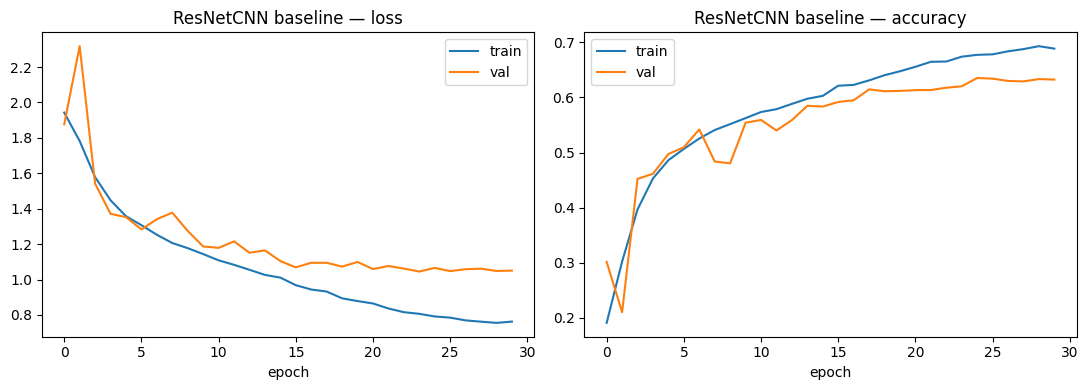


DeepCNN (tuned) test 0.666 / f1 0.659  |  ResNetCNN baseline test: 0.661 / f1 0.647


In [14]:
res_model, res_hist = fit(lambda: ResNetCNN(), arch="ResNetCNN", epochs=30, lr=1e-3,
                          batch_size=128, lr_schedule="cosine", augment=True,
                          study="baseline", run_name="ResNetCNN-baseline",
                          notes="Arch 4 baseline: compact ResNet, lr 1e-3, cosine, aug ON, dropout 0.3.")
plot_history(res_hist, title="ResNetCNN baseline")
print(f"\nDeepCNN (tuned) test 0.666 / f1 0.659  |  ResNetCNN baseline test: "
      f"{res_hist['test_acc']:.3f} / f1 {res_hist['test_f1']:.3f}")

### Search 1 — Learning rate

In [29]:
lr_df = grid_search(ResNetCNN, arch="ResNetCNN",
                    param_grid={"lr": [3e-3]},
                    fixed=dict(epochs=30, batch_size=128, lr_schedule="cosine", augment=True),
                    study="tune-lr")
display(lr_df)

BEST_LR = float(lr_df.iloc[0]["lr"])
print(f"\n>>> best LR = {BEST_LR:g}  "
      f"(val {lr_df.iloc[0]['best_val_acc']:.4f}, test {lr_df.iloc[0]['test_acc']:.4f})")

[grid] 1 combinations
--- grid 1/1: {'lr': 0.003} ---


[ResNetCNN] epoch 01/30  train_loss 1.945 acc 0.183 | val_loss 2.085 acc 0.228 f1 0.157
[ResNetCNN] epoch 02/30  train_loss 1.853 acc 0.243 | val_loss 1.767 acc 0.329 f1 0.266
[ResNetCNN] epoch 03/30  train_loss 1.672 acc 0.358 | val_loss 1.777 acc 0.335 f1 0.267
[ResNetCNN] epoch 04/30  train_loss 1.545 acc 0.416 | val_loss 1.581 acc 0.343 f1 0.335
[ResNetCNN] epoch 05/30  train_loss 1.472 acc 0.438 | val_loss 1.491 acc 0.432 f1 0.349
[ResNetCNN] epoch 06/30  train_loss 1.410 acc 0.466 | val_loss 1.398 acc 0.454 f1 0.375
[ResNetCNN] epoch 07/30  train_loss 1.347 acc 0.487 | val_loss 1.394 acc 0.503 f1 0.429
[ResNetCNN] epoch 08/30  train_loss 1.297 acc 0.504 | val_loss 1.387 acc 0.459 f1 0.403
[ResNetCNN] epoch 09/30  train_loss 1.260 acc 0.515 | val_loss 1.286 acc 0.532 f1 0.491
[ResNetCNN] epoch 10/30  train_loss 1.217 acc 0.531 | val_loss 1.298 acc 0.535 f1 0.497
[ResNetCNN] epoch 11/30  train_loss 1.180 acc 0.544 | val_loss 1.244 acc 0.536 f1 0.494
[ResNetCNN] epoch 12/30  train_l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▃▁▆█▅▅▄▇▄▅▅▅▅▅▆▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇
gap/loss,▅▁▄▃▃▂▃▄▃▄▃▄▃▃▆▅▄▄▄▆▆▇▆▆▇▇▇███
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▂▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
train/loss,█▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▃▃▃▅▅▆▅▆▆▆▆▇▇▇▇▇▇▇▇██████████
val/f1_macro,▁▃▃▄▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇██████████
val/loss,█▆▆▅▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,27
best_val_acc,0.63305


,epochs,batch_size,lr_schedule,augment,lr,best_val_acc,test_acc,test_f1
0,30,128,cosine,True,0.003,0.633,0.6484,0.6353



>>> best LR = 0.003  (val 0.6330, test 0.6484)


In [31]:
BEST_LR = 0.001
print(f"BEST_LR = {BEST_LR:g}")

BEST_LR = 0.001


### Search 2 — Label smoothing

In [38]:
ls_df = grid_search(ResNetCNN, arch="ResNetCNN",
                    param_grid={"label_smoothing": [0.05, 0.1]},
                    fixed=dict(epochs=30, batch_size=128, lr=BEST_LR, lr_schedule="cosine", augment=True),
                    study="tune-label-smoothing")
display(ls_df)

BEST_LS = float(ls_df.iloc[0]["label_smoothing"])
print(f"\n>>> best label_smoothing = {BEST_LS:g}  "
      f"(val {ls_df.iloc[0]['best_val_acc']:.4f}, test {ls_df.iloc[0]['test_acc']:.4f}, "
      f"f1 {ls_df.iloc[0]['test_f1']:.4f})")

[grid] 2 combinations
--- grid 1/2: {'label_smoothing': 0.05} ---


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁▅█▇▆█▇▇▆▆▆▇▆▆▆▆▇▇▇▇▇▇▇▇▇█▇███
gap/loss,▁▃▇▅▅▇█▆▅▅▅▆▅▆▆▆▆▆▆▇▆▇▇▇▇█████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
train/loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▂▁▃▄▃▅▅▆▆▆▆▇▇▇▇▇▇█▇██████████
val/f1_macro,▁▂▂▃▄▃▃▄▆▆▅▆▇▆▇▇▇▇▇▇██████████
val/loss,█▇█▆▅▅▆▄▃▃▃▃▂▂▃▂▂▁▁▁▁▂▁▁▁▁▁▁▁▁
epoch,30
gap/acc,0.08203


[ResNetCNN] epoch 01/30  train_loss 2.039 acc 0.154 | val_loss 1.950 acc 0.206 f1 0.165
[ResNetCNN] epoch 02/30  train_loss 1.858 acc 0.297 | val_loss 2.071 acc 0.259 f1 0.188
[ResNetCNN] epoch 03/30  train_loss 1.686 acc 0.413 | val_loss 1.644 acc 0.461 f1 0.415
[ResNetCNN] epoch 04/30  train_loss 1.592 acc 0.461 | val_loss 1.578 acc 0.451 f1 0.424
[ResNetCNN] epoch 05/30  train_loss 1.527 acc 0.498 | val_loss 1.514 acc 0.499 f1 0.440
[ResNetCNN] epoch 06/30  train_loss 1.488 acc 0.514 | val_loss 1.481 acc 0.537 f1 0.473
[ResNetCNN] epoch 07/30  train_loss 1.446 acc 0.538 | val_loss 1.478 acc 0.551 f1 0.489
[ResNetCNN] epoch 08/30  train_loss 1.414 acc 0.551 | val_loss 1.493 acc 0.519 f1 0.473
[ResNetCNN] epoch 09/30  train_loss 1.386 acc 0.568 | val_loss 1.409 acc 0.533 f1 0.471
[ResNetCNN] epoch 10/30  train_loss 1.355 acc 0.579 | val_loss 1.423 acc 0.556 f1 0.486
[ResNetCNN] epoch 11/30  train_loss 1.334 acc 0.590 | val_loss 1.366 acc 0.585 f1 0.523
[ResNetCNN] epoch 12/30  train_l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁▆▁▅▄▃▃▆▆▅▄▅▅▆▅▆▆▅▅▆▆▇▇▇▇▇████
gap/loss,▁█▂▃▃▃▄▅▃▄▄▅▅▆▄▅▅▅▆▆▆▇▇▇▇█████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train/loss,█▇▆▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▂▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█████████████
val/f1_macro,▁▁▅▅▅▆▆▆▆▆▆▆▇▆▇▇▇▇████████████
val/loss,▇█▄▄▃▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,30
best_val_acc,0.66007


--- grid 2/2: {'label_smoothing': 0.1} ---


[ResNetCNN] epoch 01/30  train_loss 2.096 acc 0.158 | val_loss 2.035 acc 0.292 f1 0.191
[ResNetCNN] epoch 02/30  train_loss 1.870 acc 0.339 | val_loss 1.996 acc 0.277 f1 0.185
[ResNetCNN] epoch 03/30  train_loss 1.761 acc 0.420 | val_loss 1.719 acc 0.512 f1 0.437
[ResNetCNN] epoch 04/30  train_loss 1.694 acc 0.472 | val_loss 1.667 acc 0.499 f1 0.453
[ResNetCNN] epoch 05/30  train_loss 1.648 acc 0.502 | val_loss 1.624 acc 0.531 f1 0.477
[ResNetCNN] epoch 06/30  train_loss 1.609 acc 0.523 | val_loss 1.601 acc 0.575 f1 0.536
[ResNetCNN] epoch 07/30  train_loss 1.581 acc 0.546 | val_loss 1.596 acc 0.567 f1 0.492
[ResNetCNN] epoch 08/30  train_loss 1.559 acc 0.559 | val_loss 1.617 acc 0.545 f1 0.493
[ResNetCNN] epoch 09/30  train_loss 1.534 acc 0.578 | val_loss 1.592 acc 0.513 f1 0.468
[ResNetCNN] epoch 10/30  train_loss 1.510 acc 0.591 | val_loss 1.591 acc 0.533 f1 0.470
[ResNetCNN] epoch 11/30  train_loss 1.492 acc 0.598 | val_loss 1.537 acc 0.578 f1 0.516
[ResNetCNN] epoch 12/30  train_l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁▇▂▄▄▄▅▆▇▇▆▆▆▇▆▇▇▇▇▇▇▇▇███████
gap/loss,▁▆▁▂▂▂▃▄▄▅▄▄▅▆▄▅▅▅▅▆▆▆▇▇▇█████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇█████████
train/loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▁▅▅▆▆▆▆▅▆▆▆▇▇▇▇▇▇████████████
val/f1_macro,▁▁▅▅▆▆▆▆▅▅▆▆▆▆▇▇▇▇▇███████████
val/loss,██▄▄▃▃▃▃▃▃▂▂▂▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,30
best_val_acc,0.66676


,epochs,batch_size,lr,lr_schedule,augment,label_smoothing,best_val_acc,test_acc,test_f1
0,30,128,0.001,cosine,True,0.10,0.6668,0.6707,0.6404
1,30,128,0.001,cosine,True,0.05,0.6601,0.6684,0.6490



>>> best label_smoothing = 0.1  (val 0.6668, test 0.6707, f1 0.6404)


In [39]:
print(BEST_LS)

0.1


### Search 3 — Capacity (width × depth)

In [42]:
cap_df = grid_search(ResNetCNN, arch="ResNetCNN",
                     param_grid={"channels": [16, 24], "blocks_per_stage": [2, 3]},
                     fixed=dict(epochs=30, batch_size=128, lr=BEST_LR, label_smoothing=BEST_LS,
                                lr_schedule="cosine", augment=True),
                     study="tune-capacity")
display(cap_df)

BEST_CH = int(cap_df.iloc[0]["channels"])
BEST_BPS = int(cap_df.iloc[0]["blocks_per_stage"])
print(f"\n>>> best capacity = channels {BEST_CH}, blocks/stage {BEST_BPS}  "
      f"(val {cap_df.iloc[0]['best_val_acc']:.4f}, test {cap_df.iloc[0]['test_acc']:.4f}, "
      f"f1 {cap_df.iloc[0]['test_f1']:.4f})")

[grid] 4 combinations
--- grid 1/4: {'channels': 16, 'blocks_per_stage': 2} ---


[ResNetCNN] epoch 01/30  train_loss 2.096 acc 0.135 | val_loss 2.028 acc 0.277 f1 0.201
[ResNetCNN] epoch 02/30  train_loss 1.905 acc 0.308 | val_loss 1.963 acc 0.316 f1 0.276
[ResNetCNN] epoch 03/30  train_loss 1.786 acc 0.401 | val_loss 1.763 acc 0.483 f1 0.430
[ResNetCNN] epoch 04/30  train_loss 1.724 acc 0.448 | val_loss 1.760 acc 0.533 f1 0.472
[ResNetCNN] epoch 05/30  train_loss 1.677 acc 0.482 | val_loss 1.703 acc 0.519 f1 0.465
[ResNetCNN] epoch 06/30  train_loss 1.641 acc 0.506 | val_loss 1.644 acc 0.536 f1 0.470
[ResNetCNN] epoch 07/30  train_loss 1.616 acc 0.522 | val_loss 1.626 acc 0.539 f1 0.496
[ResNetCNN] epoch 08/30  train_loss 1.593 acc 0.539 | val_loss 1.614 acc 0.568 f1 0.520
[ResNetCNN] epoch 09/30  train_loss 1.565 acc 0.555 | val_loss 1.626 acc 0.540 f1 0.475
[ResNetCNN] epoch 10/30  train_loss 1.545 acc 0.566 | val_loss 1.567 acc 0.557 f1 0.507
[ResNetCNN] epoch 11/30  train_loss 1.528 acc 0.573 | val_loss 1.570 acc 0.564 f1 0.505
[ResNetCNN] epoch 12/30  train_l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁▆▃▃▅▅▅▅▆▆▆▆▇▇▇▆▇▇▇▇▇█▇▇▇█████
gap/loss,▁▅▂▄▄▃▃▄▅▄▄▄▅▆▅▅▅▆▆▆▇▇▇▇▇▇████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
train/loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val/acc,▁▂▅▆▆▆▆▆▆▆▆▇▆▆▇█▇▇▇██▇████████
val/f1_macro,▁▂▅▆▅▆▆▆▆▆▆▇▆▆▇▇▇▇▇█▇▇████████
val/loss,█▇▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
best_epoch,28
best_val_acc,0.65004


--- grid 2/4: {'channels': 16, 'blocks_per_stage': 3} ---


[ResNetCNN] epoch 01/30  train_loss 2.132 acc 0.073 | val_loss 2.038 acc 0.108 f1 0.079
[ResNetCNN] epoch 02/30  train_loss 1.971 acc 0.229 | val_loss 1.920 acc 0.230 f1 0.214
[ResNetCNN] epoch 03/30  train_loss 1.843 acc 0.360 | val_loss 1.895 acc 0.385 f1 0.309
[ResNetCNN] epoch 04/30  train_loss 1.781 acc 0.415 | val_loss 1.776 acc 0.435 f1 0.359
[ResNetCNN] epoch 05/30  train_loss 1.724 acc 0.456 | val_loss 1.856 acc 0.402 f1 0.342
[ResNetCNN] epoch 06/30  train_loss 1.690 acc 0.482 | val_loss 1.679 acc 0.478 f1 0.417
[ResNetCNN] epoch 07/30  train_loss 1.662 acc 0.503 | val_loss 1.742 acc 0.446 f1 0.383
[ResNetCNN] epoch 08/30  train_loss 1.630 acc 0.521 | val_loss 1.629 acc 0.524 f1 0.474
[ResNetCNN] epoch 09/30  train_loss 1.607 acc 0.531 | val_loss 1.633 acc 0.539 f1 0.486
[ResNetCNN] epoch 10/30  train_loss 1.585 acc 0.548 | val_loss 1.585 acc 0.553 f1 0.485
[ResNetCNN] epoch 11/30  train_loss 1.564 acc 0.562 | val_loss 1.615 acc 0.532 f1 0.474
[ResNetCNN] epoch 12/30  train_l

...

--- grid 4/4: {'channels': 24, 'blocks_per_stage': 3} ---


[ResNetCNN] epoch 01/30  train_loss 2.112 acc 0.135 | val_loss 2.084 acc 0.220 f1 0.166
[ResNetCNN] epoch 02/30  train_loss 1.915 acc 0.300 | val_loss 1.830 acc 0.388 f1 0.314
[ResNetCNN] epoch 03/30  train_loss 1.797 acc 0.400 | val_loss 1.756 acc 0.438 f1 0.370
[ResNetCNN] epoch 04/30  train_loss 1.724 acc 0.457 | val_loss 1.708 acc 0.449 f1 0.402
[ResNetCNN] epoch 05/30  train_loss 1.672 acc 0.491 | val_loss 1.702 acc 0.478 f1 0.439
[ResNetCNN] epoch 06/30  train_loss 1.637 acc 0.516 | val_loss 1.613 acc 0.537 f1 0.476
[ResNetCNN] epoch 07/30  train_loss 1.601 acc 0.536 | val_loss 1.627 acc 0.558 f1 0.513
[ResNetCNN] epoch 08/30  train_loss 1.576 acc 0.555 | val_loss 1.612 acc 0.552 f1 0.481
[ResNetCNN] epoch 09/30  train_loss 1.559 acc 0.566 | val_loss 1.586 acc 0.545 f1 0.495
[ResNetCNN] epoch 10/30  train_loss 1.536 acc 0.579 | val_loss 1.604 acc 0.550 f1 0.513
[ResNetCNN] epoch 11/30  train_loss 1.513 acc 0.589 | val_loss 1.530 acc 0.576 f1 0.524
[ResNetCNN] epoch 12/30  train_l

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
gap/acc,▁▁▃▅▅▄▄▅▅▆▅▅▅▆▆▅▆▆▆▆▇▇▇▇▇█████
gap/loss,▂▁▂▃▄▂▄▄▄▅▃▅▅▄▅▅▆▆▆▆▆▆▇▇▇█████
lr,██████▇▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train/loss,█▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val/acc,▁▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇████████████
val/f1_macro,▁▃▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████
val/loss,█▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
best_epoch,29
best_val_acc,0.65645


,epochs,batch_size,lr,label_smoothing,lr_schedule,augment,channels,blocks_per_stage,best_val_acc,test_acc,test_f1
0,30,128,0.001,0.1,cosine,True,24,2,0.6631,0.6746,0.6401
1,30,128,0.001,0.1,cosine,True,24,3,0.6565,0.6793,0.6581
2,30,128,0.001,0.1,cosine,True,16,2,0.6500,0.6615,0.6165
3,30,128,0.001,0.1,cosine,True,16,3,0.6431,0.6612,0.6268



>>> best capacity = channels 24, blocks/stage 2  (val 0.6631, test 0.6746, f1 0.6401)


In [43]:
print(BEST_CH, BEST_BPS)


24 2


### Search 4 / Final — long run + test-time augmentation

[ResNetCNN] epoch 01/60  train_loss 2.084 acc 0.169 | val_loss 2.084 acc 0.289 f1 0.212
[ResNetCNN] epoch 02/60  train_loss 1.848 acc 0.359 | val_loss 1.955 acc 0.246 f1 0.204
[ResNetCNN] epoch 03/60  train_loss 1.749 acc 0.430 | val_loss 1.751 acc 0.490 f1 0.439
[ResNetCNN] epoch 04/60  train_loss 1.689 acc 0.477 | val_loss 1.658 acc 0.490 f1 0.424
[ResNetCNN] epoch 05/60  train_loss 1.646 acc 0.504 | val_loss 1.721 acc 0.494 f1 0.413
[ResNetCNN] epoch 06/60  train_loss 1.618 acc 0.517 | val_loss 1.627 acc 0.556 f1 0.514
[ResNetCNN] epoch 07/60  train_loss 1.583 acc 0.546 | val_loss 1.606 acc 0.567 f1 0.493
[ResNetCNN] epoch 08/60  train_loss 1.565 acc 0.554 | val_loss 1.597 acc 0.542 f1 0.489
[ResNetCNN] epoch 09/60  train_loss 1.542 acc 0.572 | val_loss 1.570 acc 0.533 f1 0.483
[ResNetCNN] epoch 10/60  train_loss 1.524 acc 0.584 | val_loss 1.558 acc 0.558 f1 0.491
[ResNetCNN] epoch 11/60  train_loss 1.508 acc 0.589 | val_loss 1.526 acc 0.586 f1 0.533
[ResNetCNN] epoch 12/60  train_l

epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇███
gap/acc,▁▆▂▃▄▃▄▄▄▅▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████████
gap/loss,▁▃▂▁▁▂▁▂▂▂▂▃▃▃▂▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇██████
lr,██████████▇▇▇▇▇▆▆▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train/acc,▁▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████████████
train/loss,█▆▆▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
val/acc,▂▁▅▅▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇█████████████████████
val/f1_macro,▁▅▄▆▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇████▇████████████████
val/loss,█▇▄▃▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂
best_epoch,49
best_val_acc,0.68013


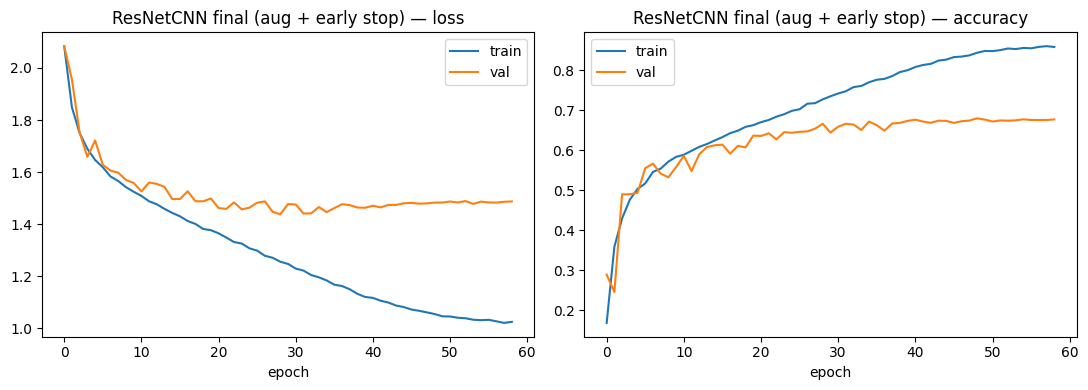


ResNetCNN FINAL: best val 0.6801 @ ep 49 (stopped 59)
  plain test acc 0.6860 / f1 0.6599
  + TTA test acc 0.6924 / f1 0.6600  (margin +0.0064)


In [45]:
res_final, res_final_hist = fit(
    lambda: ResNetCNN(channels=BEST_CH, blocks_per_stage=BEST_BPS), arch="ResNetCNN",
    epochs=60, lr=BEST_LR, batch_size=128, label_smoothing=BEST_LS, augment=True,
    lr_schedule="cosine", early_stop_patience=10, early_stop_min_delta=0.001,
    study="final", run_name="ResNetCNN-final-aug-earlystop", watch=True,
    notes="Final ResNetCNN: best lr/label-smoothing/capacity, cosine, aug, max 60 ep, early-stop patience 10.")
plot_history(res_final_hist, title="ResNetCNN final (aug + early stop)")

_, _, test_loader = make_loaders(batch_size=128, augment=False)
tta = evaluate_tta(res_final, test_loader)
print(f"\nResNetCNN FINAL: best val {res_final_hist['best_val_acc']:.4f} "
      f"@ ep {res_final_hist['best_epoch']} (stopped {res_final_hist['stopped_epoch']})")
print(f"  plain test acc {res_final_hist['test_acc']:.4f} / f1 {res_final_hist['test_f1']:.4f}")
print(f"  + TTA test acc {tta['acc']:.4f} / f1 {tta['f1_macro']:.4f}  "
      f"(margin {tta['acc'] - res_final_hist['test_acc']:+.4f})")